# Conformal factor iteration (brute-force)

This notebook demonstrates the iteration from the pasted algorithm, using a brute-force $O(N^2)$ particle-particle summation in place of FMM.

Outputs:
- Convergence diagnostics
- A 1D slice of $\psi$ along the $x$-axis

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Robustly add the project root to sys.path so we can import from ./src
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = None
for p in candidates:
    if (p / 'src' / 'conformal_solver.py').exists():
        project_root = p
        break
if project_root is None:
    raise FileNotFoundError("Could not find src/conformal_solver.py from current working directory")
sys.path.insert(0, str(project_root))

from src.conformal_solver import ConformalFactorSolver  # noqa: E402

In [2]:
# Step 1: create a discrete cloud of interpolation points.
# For this demo we use a small uniform Cartesian grid in a box.
L = 2.0
n = 15  # keep small; brute-force is O(N^2)
xs = np.linspace(-L, L, n)
dx = xs[1] - xs[0]
X, Y, Z = np.meshgrid(xs, xs, xs, indexing='ij')
r = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

volumes = np.full(r.shape[0], dx**3)

# Define a toy potential V(r).
# Use a smooth compact-ish bump via a Gaussian truncated by the box.
sigma = 0.5
r2 = np.sum(r*r, axis=1)
V = np.exp(-r2 / (2*sigma**2))

# Optional: emulate 'support where V != 0' by dropping tiny values
eps = 1e-6
mask = V > eps
r_c = r[mask]
V_c = V[mask]
vol_c = volumes[mask]

r.shape, r_c.shape

((3375, 3), (2771, 3))

In [3]:
# Run the iteration (steps 4-11).
# M here is the parameter in the paper: M_ADM = 2M, ψ → 1 + M/r at infinity.
M = 1.0
solver = ConformalFactorSolver(r_c, V_c, vol_c, M=M, softening=0.5*dx, exclude_self=True)

psi, info = solver.solve(tol=1e-11, max_iter=200, error_norm='linf', verbose=True)
chi = psi - 1.0  # mass-normalized chi; use as input to psi_at_points

# Verify the mass condition: sum(m) should equal -M
m = solver.masses_from_chi(chi)
print(f"\nsum(m) = {m.sum():.10f}  (should be -M = {-M})")

# Physical psi at grid points via step 12 (brute-force summation of converged masses)
psi_grid = solver.psi_at_points(r_c, chi=chi)
print(f"psi (step 12) at grid points: min={psi_grid.min():.6f}  max={psi_grid.max():.6f}")

info

iter    0  err=6.624e-01
iter    1  err=3.838e-02
iter    2  err=4.903e-03
iter    3  err=5.330e-04
iter    4  err=6.060e-05
iter    5  err=6.752e-06
iter    6  err=7.581e-07
iter    7  err=8.484e-08
iter    8  err=9.507e-09
iter    9  err=1.065e-09
iter   10  err=1.193e-10
iter   11  err=1.336e-11
iter   12  err=1.497e-12

sum(m) = -1.0000000000  (should be -M = -1.0)
psi (step 12) at grid points: min=1.383536  max=2.677255


ConvergenceInfo(iterations=13, converged=True, last_error=1.496580637194711e-12)

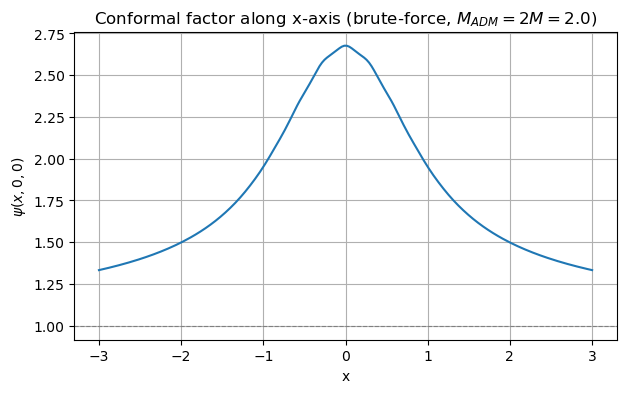

In [4]:
# Step 12: evaluate psi along the x-axis at y=z=0 using brute-force summation.
# ψ(r) = 1 − Σ_a m_a / |r − r_a|  (1/(4π) absorbed into masses)
K = 200
xline = np.linspace(-3.0, 3.0, K)
r_eval = np.column_stack([xline, np.zeros_like(xline), np.zeros_like(xline)])
psi_line = solver.psi_at_points(r_eval, chi=chi)

plt.figure(figsize=(7, 4))
plt.plot(xline, psi_line)
plt.axhline(1.0, color='gray', ls='--', lw=0.8)
plt.xlabel('x')
plt.ylabel(r'$\psi(x,0,0)$')
plt.title(r'Conformal factor along x-axis (brute-force, $M_{ADM}=2M=$' + f'{2*M})')
plt.grid(True)
plt.show()